**Evaluate the utility of new Netherton syndrome annotations**

HPO has been improved to include terms for describing Netherton syndrome.

We would like to see what difference do the new terms make, when compared with the previous terms, in phenotype-driven disease prioritizers such as *LIRICAL*.

Therefore, we take the phenopackets annotated with the new terms, "age" them to include the terms present in an older HPO version, run LIRICAL with both new and aged phenopackets, and check for differences in *Netherton syndrome* ranks.

The same analysis is then applied to 6 *Omenn syndrome* case reports.

In [1]:
import os
import pathlib
import typing

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

# Netherton syndrome

[Netherton syndrome (MIM: 256500)](https://omim.org/entry/256500)

## "Age" the phenopackets

Path to phenopackets

In [2]:
fpath_cwd = pathlib.Path(os.getcwd())
fpath_netherton_pps = fpath_cwd.joinpath('netherton-phenopackets')
fpath_original_ppdir = fpath_netherton_pps.joinpath('current')

In [3]:
from google.protobuf.json_format import Parse, MessageToJson
from phenopackets.schema.v2.phenopackets_pb2 import Phenopacket

phenopackets = []
for fpath_pp in fpath_original_ppdir.glob("PMID*.json"):
    with fpath_pp.open() as fh:
        pp = Parse(fh.read(), Phenopacket())
        phenopackets.append(pp)

len(phenopackets)

12

### HPO versions

#### Old HPO

In [4]:
import hpotk

In [5]:
hpo_old_tag = 'v2023-10-09'

store = hpotk.configure_ontology_store()
hpo_old = store.load_minimal_hpo(release=hpo_old_tag)
hpo_old.version

'2023-10-09'

#### New HPO

In [6]:
fpath_hpo_new = fpath_cwd.joinpath('data').joinpath('current').joinpath('hp.json')

print(f'Loading HPO from `{fpath_hpo_new}`')
hpo_new = hpotk.load_minimal_ontology(str(fpath_hpo_new))
hpo_new.version

Loading HPO from `/home/ielis/analysis/phenotypes/GPC-Netherton/data/current/hp.json`


'2025-11-21'

### Check HPO terms

Are all HPO terms in the new HPO?

In [7]:
unknown_curies = set()

for pp in phenopackets:
    for pf in pp.phenotypic_features:
        curie = pf.type.id
        if curie not in hpo_new:
            unknown_curies.add(curie)

if unknown_curies:
    print(f'Unknown curies: {unknown_curies}')
else:
    print('No unknown curies')

No unknown curies


Are all HPO terms in the old HPO?

In [8]:
for pp in phenopackets:
    for pf in pp.phenotypic_features:
        curie = pf.type.id
        if curie not in hpo_old:
            unknown_curies.add(curie)

if unknown_curies:
    unknown_curies = tuple(unknown_curies)
    print(f'Unknown curies: {unknown_curies}')
    print(f'Unknown labels: {tuple(hpo_new.get_term_name(curie) for curie in unknown_curies)}')
else:
    print('No unknown curies')

Unknown curies: ('HP:0025811', 'HP:0025810', 'HP:6001166', 'HP:0025809', 'HP:0025819', 'HP:0025816')
Unknown labels: ('Trichorrhexis invaginata', 'Ichthyosis linearis circumflexa', 'Spongiosis', 'Generalized scaling', 'Palmoplantar peeling', 'Hypogranulosis')


### Generalize the HPO terms

In [9]:
def generalize_hpo_set(
    hpo_old: hpotk.MinimalOntology,
    hpo_new: hpotk.MinimalOntology,
    curies: typing.Collection[str],
) -> typing.Collection[str]:
    sanitized = set()
    for curie in curies:
        if curie in hpo_old:
            sanitized.add(curie)
        else:
            assert curie in hpo_new, "It should be in the new though!"
            parents = list(hpo_new.graph.get_parents(curie))
            
            while parents:
                current = parents.pop()
                if current in hpo_old:
                    print(f'Replacing {hpo_new.get_term_name(curie)} [{curie}] with {hpo_new.get_term_name(current)} [{current}]')
                    sanitized.add(current.value)
                    break
                else:
                    parents.extend(hpo_new.graph.get_parents(current))
    
    return sanitized

In [10]:
from phenopackets.schema.v2.core.base_pb2 import OntologyClass
from phenopackets.schema.v2.core.phenotypic_feature_pb2 import PhenotypicFeature

generalized = []
for pp in phenopackets:
    print(f'Phenopacket {pp.id} - {pp.subject.id}')
    curies = tuple(pf.type.id for pf in pp.phenotypic_features)
    updated_curies = generalize_hpo_set(
        hpo_old=hpo_old,
        hpo_new=hpo_new,
        curies=curies,
    )

    updated = Phenopacket()
    updated.CopyFrom(pp)
    updated.phenotypic_features.clear()
    for curie in updated_curies:
        updated.phenotypic_features.append(
            PhenotypicFeature(
                type=OntologyClass(
                    id=curie,
                    label=hpo_new.get_term_name(curie)
                )
            )
        )
    generalized.append(updated)
    print()

Phenopacket PMID_1_Individual_7 - Individual 7
Replacing Ichthyosis linearis circumflexa [HP:0025810] with Ichthyosis [HP:0008064]
Replacing Generalized scaling [HP:0025809] with Scaling skin [HP:0040189]
Replacing Spongiosis [HP:6001166] with Abnormal epidermal morphology [HP:0011124]
Replacing Trichorrhexis invaginata [HP:0025811] with Abnormal hairshaft morphology [HP:0003328]

Phenopacket PMID_1_Individual_11 - Individual 11
Replacing Palmoplantar peeling [HP:0025819] with Abnormality of the plantar skin of foot [HP:0100872]
Replacing Ichthyosis linearis circumflexa [HP:0025810] with Ichthyosis [HP:0008064]
Replacing Generalized scaling [HP:0025809] with Scaling skin [HP:0040189]

Phenopacket PMID_1_Individual_4 - Individual 4
Replacing Palmoplantar peeling [HP:0025819] with Abnormality of the plantar skin of foot [HP:0100872]
Replacing Ichthyosis linearis circumflexa [HP:0025810] with Ichthyosis [HP:0008064]
Replacing Trichorrhexis invaginata [HP:0025811] with Abnormal hairshaft m

### Serialize the aged phenopackets

In [11]:
fpath_ppdir_updated = fpath_netherton_pps.joinpath('older')

for pp in generalized:
    fpath_pp = fpath_ppdir_updated.joinpath(f'{pp.id}.json')
    with fpath_pp.open(mode='w') as fh:
        fh.write(MessageToJson(pp))

print(f'Wrote {len(generalized)} phenopackets to `{fpath_ppdir_updated}`')

Wrote 12 phenopackets to `/home/ielis/analysis/phenotypes/GPC-Netherton/netherton-phenopackets/older`


## Run *LIRICAL*

We run LIRICAL to compute the *Netherton syndrome* ranks.

We evaluate several resource releases:
- *older* - `v2023-10-09`
- *latest* - `v2025-10-22` - latest official HPO release as of Nov 21, 2025
- *current* - not yet released, built on Nov 21st, 2025

```shell
module load lirical/2.2.1

WORKDIR="/home/ielis/analysis/phenotypes/GPC-Netherton" 
cd "${WORKDIR}"

# Run older phenopackets
OLD_DATA="${WORKDIR}/data/older"
OLD_PHENOPACKET_DIR="${WORKDIR}/netherton-phenopackets/older"
lirical benchmark -d ${OLD_DATA} -o netherton.older.csv "${OLD_PHENOPACKET_DIR}"/*.json

# Run latest release phenopackets
LATEST_DATA="${WORKDIR}/data/latest"
LATEST_PHENOPACKET_DIR="${WORKDIR}/netherton-phenopackets/latest"
lirical benchmark -d ${LATEST_DATA} -o netherton.latest.csv "${LATEST_PHENOPACKET_DIR}"/*.json

# Run current release phenopackets
CURRENT_DATA="${WORKDIR}/data/current"
CURRENT_PHENOPACKET_DIR="${WORKDIR}/netherton-phenopackets/current"
lirical benchmark -d ${CURRENT_DATA} -o netherton.current.csv "${CURRENT_PHENOPACKET_DIR}"/*.json
```

## Evaluate ranks

[Netherton syndrome (MIM: 256500)](https://omim.org/entry/256500)

In [12]:
fpath_old_ranks = fpath_cwd.joinpath('netherton.older.csv')
df_old_ranks = pd.read_csv(fpath_old_ranks)

fpath_latest_ranks = fpath_cwd.joinpath('netherton.latest.csv')
df_latest_ranks = pd.read_csv(fpath_latest_ranks)

fpath_current_ranks = fpath_cwd.joinpath('netherton.current.csv')
df_current_ranks = pd.read_csv(fpath_current_ranks)

df_old_ranks.shape, df_latest_ranks.shape, df_current_ranks.shape

((98736, 7), (100740, 7), (100992, 7))

In [13]:
df_old_ranks.head(2)

,phenopacket,background_vcf,sample_id,rank,is_causal,disease_id,post_test_proba
0,PMID_1_Individual_10.json,NaN,Individual 10,1,False,OMIM:603165,1.000000
1,PMID_1_Individual_10.json,NaN,Individual 10,2,False,OMIM:618131,0.993564


In [14]:
df_old_data = df_old_ranks.loc[df_old_ranks.is_causal, ['phenopacket', 'rank', 'post_test_proba']].set_index('phenopacket')
df_old_data.head(2)

,rank,post_test_proba
phenopacket,,
PMID_1_Individual_10.json,4,0.005110
PMID_1_Individual_11.json,3,0.995624


In [15]:
df_latest_data = df_latest_ranks.loc[df_latest_ranks.is_causal, ['phenopacket', 'rank', 'post_test_proba']].set_index('phenopacket')
df_latest_data.head(2)

,rank,post_test_proba
phenopacket,,
PMID_1_Individual_10.json,7,0.000023
PMID_1_Individual_11.json,5,0.769097


In [16]:
df_current_data = df_current_ranks.loc[df_current_ranks.is_causal, ['phenopacket', 'rank', 'post_test_proba']].set_index('phenopacket')
df_current_data.head(2)

,rank,post_test_proba
phenopacket,,
PMID_1_Individual_10.json,1,1.0
PMID_1_Individual_11.json,1,1.0


### Ranks and post-test probabilities

Show Netherton syndrome ranks as determined by LIRICAL in phenotype-only mode.

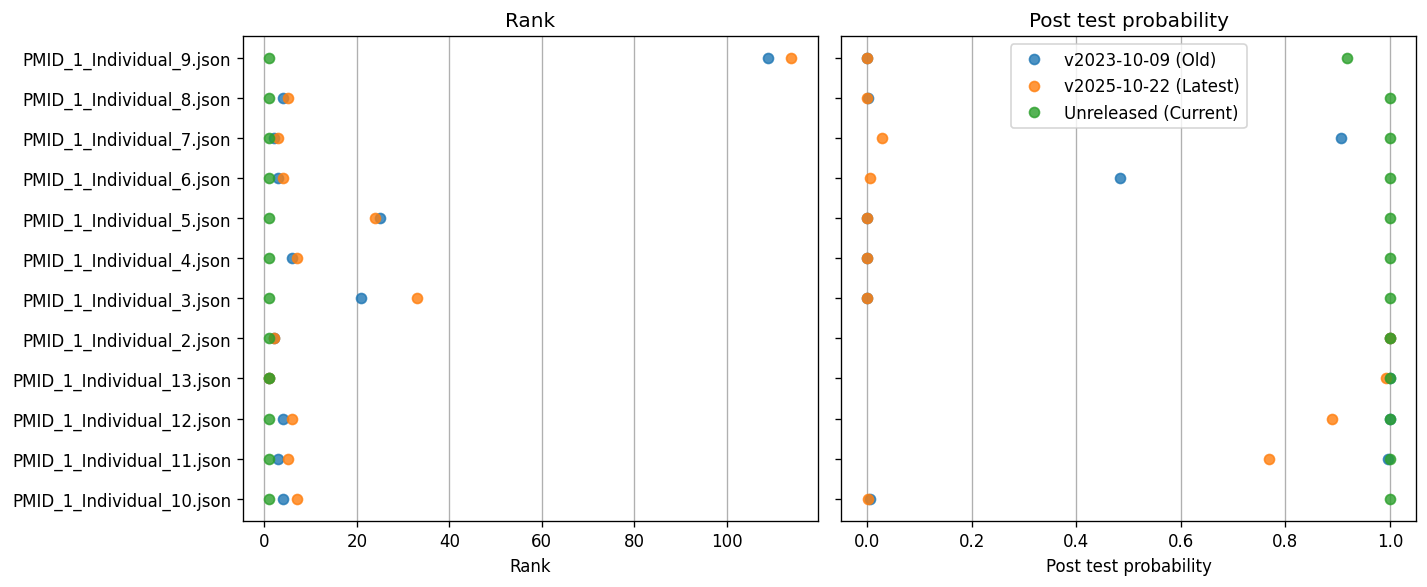

In [17]:
fig, (ax_ranks, ax_probas) = plt.subplots(1, 2, figsize=(12, 5), dpi=120, sharey=True)

ax_ranks.grid(axis='x')
ax_ranks.plot(df_old_data['rank'], df_old_data.index, 'o', alpha=.8, label='v2023-10-09 (Old)')
ax_ranks.plot(df_latest_data['rank'], df_latest_data.index, 'o', alpha=.8, label='v2025-10-22 (Latest)')
ax_ranks.plot(df_current_data['rank'], df_current_data.index, 'o', alpha=.8, label='Current')
ax_ranks.set(xlabel='Rank', title='Rank')

ax_probas.grid(axis='x')
ax_probas.plot(df_old_data['post_test_proba'], df_old_data.index, 'o', alpha=.8, label='v2023-10-09 (Old)')
ax_probas.plot(df_latest_data['post_test_proba'], df_latest_data.index, 'o', alpha=.8, label='v2025-10-22 (Latest)')
ax_probas.plot(df_current_data['post_test_proba'], df_current_data.index, 'o', alpha=.8, label='Unreleased (Current)')
ax_probas.set(xlabel='Post test probability', title='Post test probability')
ax_probas.legend()

fig.tight_layout()

### Rank distributions

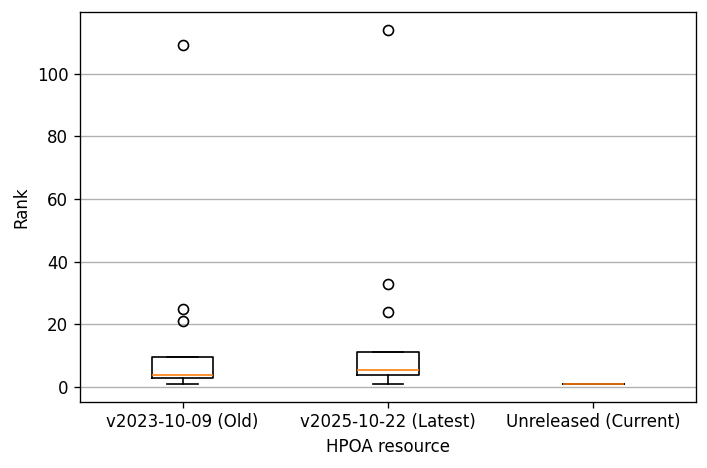

In [18]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120,)

ax.grid(axis='y')
_ = ax.boxplot(
    x=[
        df_old_data['rank'],
        df_latest_data['rank'],
        df_current_data['rank']
    ],
    tick_labels=('v2023-10-09 (Old)', 'v2025-10-22 (Latest)', 'Unreleased (Current)'),
)
ax.set(xlabel='HPOA resource', ylabel='Rank',)
fig.tight_layout()

### Actual ranks

In [19]:
pd.concat(
    (
        pd.Series(df_old_data['rank'], name='v2023-10-09 (Old)'),
        pd.Series(df_latest_data['rank'], name='v2025-10-22 (Latest)'),
        pd.Series(df_current_data['rank'], name='Unreleased (Current)'),
    ),
    axis=1
)


,v2023-10-09 (Old),v2025-10-22 (Latest),Unreleased (Current)
phenopacket,,,
PMID_1_Individual_10.json,4,7,1
PMID_1_Individual_11.json,3,5,1
PMID_1_Individual_12.json,4,6,1
PMID_1_Individual_13.json,1,1,1
PMID_1_Individual_2.json,2,2,1
PMID_1_Individual_3.json,21,33,1
PMID_1_Individual_4.json,6,7,1
PMID_1_Individual_5.json,25,24,1
PMID_1_Individual_6.json,3,4,1


# Omenn syndrome

## "Age" the phenopackets

Path to phenopackets

In [20]:
fpath_cwd = pathlib.Path(os.getcwd())
fpath_omenn_pps = fpath_cwd.joinpath('omenn-phenopackets')
fpath_original_ppdir = fpath_omenn_pps.joinpath('current')

In [21]:
phenopackets = []
for fpath_pp in fpath_original_ppdir.glob("PMID*.json"):
    with fpath_pp.open() as fh:
        pp = Parse(fh.read(), Phenopacket())
        phenopackets.append(pp)

len(phenopackets)

6

### HPO versions

#### Old HPO

In [22]:
hpo_old_tag = 'v2023-10-09'

store = hpotk.configure_ontology_store()
hpo_old = store.load_minimal_hpo(release=hpo_old_tag)
hpo_old.version

'2023-10-09'

#### New HPO

In [23]:
fpath_hpo_new = fpath_cwd.joinpath('data').joinpath('current').joinpath('hp.json')

print(f'Loading HPO from `{fpath_hpo_new}`')
hpo_new = hpotk.load_minimal_ontology(str(fpath_hpo_new))
hpo_new.version

Loading HPO from `/home/ielis/analysis/phenotypes/GPC-Netherton/data/current/hp.json`


'2025-11-21'

### Check HPO terms

Are all HPO terms in the new HPO?

In [24]:
unknown_curies = set()

for pp in phenopackets:
    for pf in pp.phenotypic_features:
        curie = pf.type.id
        if curie not in hpo_new:
            unknown_curies.add(curie)

if unknown_curies:
    print(f'Unknown curies: {unknown_curies}')
else:
    print('No unknown curies')

No unknown curies


Are all HPO terms in the old HPO?

In [25]:
for pp in phenopackets:
    for pf in pp.phenotypic_features:
        curie = pf.type.id
        if curie not in hpo_old:
            unknown_curies.add(curie)

if unknown_curies:
    unknown_curies = tuple(unknown_curies)
    print(f'Unknown curies: {unknown_curies}')
    print(f'Unknown labels: {tuple(hpo_new.get_term_name(curie) for curie in unknown_curies)}')
else:
    print('No unknown curies')

Unknown curies: ('HP:0020116', 'HP:0025811', 'HP:6001166', 'HP:0025817', 'HP:0025805')
Unknown labels: ('Subcutaneous abscess', 'Trichorrhexis invaginata', 'Spongiosis', 'Psoriasiform acanthosis', 'Absent circulating T cells')


### Generalize the HPO terms

In [26]:
from phenopackets.schema.v2.core.base_pb2 import OntologyClass
from phenopackets.schema.v2.core.phenotypic_feature_pb2 import PhenotypicFeature

generalized = []
for pp in phenopackets:
    print(f'Phenopacket {pp.id} - {pp.subject.id}')
    curies = tuple(pf.type.id for pf in pp.phenotypic_features)
    updated_curies = generalize_hpo_set(
        hpo_old=hpo_old,
        hpo_new=hpo_new,
        curies=curies,
    )

    updated = Phenopacket()
    updated.CopyFrom(pp)
    updated.phenotypic_features.clear()
    for curie in updated_curies:
        updated.phenotypic_features.append(
            PhenotypicFeature(
                type=OntologyClass(
                    id=curie,
                    label=hpo_new.get_term_name(curie)
                )
            )
        )
    generalized.append(updated)
    print()

Phenopacket PMID_19830075_Case_presentation - Case presentation

Phenopacket PMID_25849362_P1 - P1
Replacing Spongiosis [HP:6001166] with Abnormal epidermal morphology [HP:0011124]
Replacing Trichorrhexis invaginata [HP:0025811] with Abnormal hairshaft morphology [HP:0003328]

Phenopacket PMID_15731174_Patient - Patient

Phenopacket PMID_28414192_girl - girl
Replacing Absent circulating T cells [HP:0025805] with Abnormal total T cell count [HP:0011839]
Replacing Subcutaneous abscess [HP:0020116] with Abscess [HP:0025615]
Replacing Psoriasiform acanthosis [HP:0025817] with Epidermal acanthosis [HP:0025092]
Replacing Spongiosis [HP:6001166] with Abnormal epidermal morphology [HP:0011124]

Phenopacket PMID_19011808_Case_report - Case report

Phenopacket PMID_37269334_patient - patient



### Serialize the aged phenopackets

In [27]:
fpath_ppdir_updated = fpath_omenn_pps.joinpath('older')

for pp in generalized:
    fpath_pp = fpath_ppdir_updated.joinpath(f'{pp.id}.json')
    with fpath_pp.open(mode='w') as fh:
        fh.write(MessageToJson(pp))

print(f'Wrote {len(generalized)} phenopackets to `{fpath_ppdir_updated}`')

Wrote 6 phenopackets to `/home/ielis/analysis/phenotypes/GPC-Netherton/omenn-phenopackets/older`


## Run *LIRICAL*

We run LIRICAL to compute the *Omenn syndrome* ranks.

We evaluate several resource releases:
- *older* - `v2023-10-09`
- *current* - not yet released, built on Nov 21st, 2025

```shell
module load lirical/2.2.1

WORKDIR="/home/ielis/analysis/phenotypes/GPC-Netherton" 
cd "${WORKDIR}"

# Run older phenopackets
OLD_DATA="${WORKDIR}/data/older"
OLD_PHENOPACKET_DIR="${WORKDIR}/omenn-phenopackets/older"
lirical benchmark -d ${OLD_DATA} -o omenn.older.csv "${OLD_PHENOPACKET_DIR}"/*.json

# # Run latest release phenopackets
# LATEST_DATA="${WORKDIR}/data/latest"
# LATEST_PHENOPACKET_DIR="${WORKDIR}/omenn-phenopackets/latest"
# lirical benchmark -d ${LATEST_DATA} -o omenn.latest.csv "${LATEST_PHENOPACKET_DIR}"/*.json

# Run current release phenopackets
CURRENT_DATA="${WORKDIR}/data/current"
CURRENT_PHENOPACKET_DIR="${WORKDIR}/omenn-phenopackets/current"
lirical benchmark -d ${CURRENT_DATA} -o omenn.current.csv "${CURRENT_PHENOPACKET_DIR}"/*.json
```

## Evaluate ranks

[Omenn syndrome (MIM: 603554)](https://omim.org/entry/603554)

In [28]:
fpath_old_ranks = fpath_cwd.joinpath('omenn.older.csv')
df_old_ranks = pd.read_csv(fpath_old_ranks)

# fpath_latest_ranks = fpath_cwd.joinpath('omenn.latest.csv')
# df_latest_ranks = pd.read_csv(fpath_latest_ranks)

fpath_current_ranks = fpath_cwd.joinpath('omenn.current.csv')
df_current_ranks = pd.read_csv(fpath_current_ranks)

# df_old_ranks.shape, df_latest_ranks.shape, df_current_ranks.shape
df_old_ranks.shape, df_current_ranks.shape

((49368, 7), (50496, 7))

In [29]:
df_old_ranks.head(2)

,phenopacket,background_vcf,sample_id,rank,is_causal,disease_id,post_test_proba
0,PMID_15731174_Patient.json,NaN,Patient,1,False,OMIM:602450,1.0
1,PMID_15731174_Patient.json,NaN,Patient,2,False,OMIM:606367,1.0


In [30]:
df_old_data = df_old_ranks.loc[df_old_ranks.is_causal, ['phenopacket', 'rank', 'post_test_proba']].set_index('phenopacket')
df_old_data.head(2)

,rank,post_test_proba
phenopacket,,
PMID_15731174_Patient.json,26,4.033024e-08
PMID_19011808_Case_report.json,1,1.000000e+00


In [31]:
# df_latest_data = df_latest_ranks.loc[df_latest_ranks.is_causal, ['phenopacket', 'rank', 'post_test_proba']].set_index('phenopacket')
# df_latest_data.head(2)

In [32]:
df_current_data = df_current_ranks.loc[df_current_ranks.is_causal, ['phenopacket', 'rank', 'post_test_proba']].set_index('phenopacket')
df_current_data.head(2)

,rank,post_test_proba
phenopacket,,
PMID_15731174_Patient.json,16,5.464642e-07
PMID_19011808_Case_report.json,1,1.000000e+00


### Ranks and post-test probabilities

Show Netherton syndrome ranks as determined by LIRICAL in phenotype-only mode.

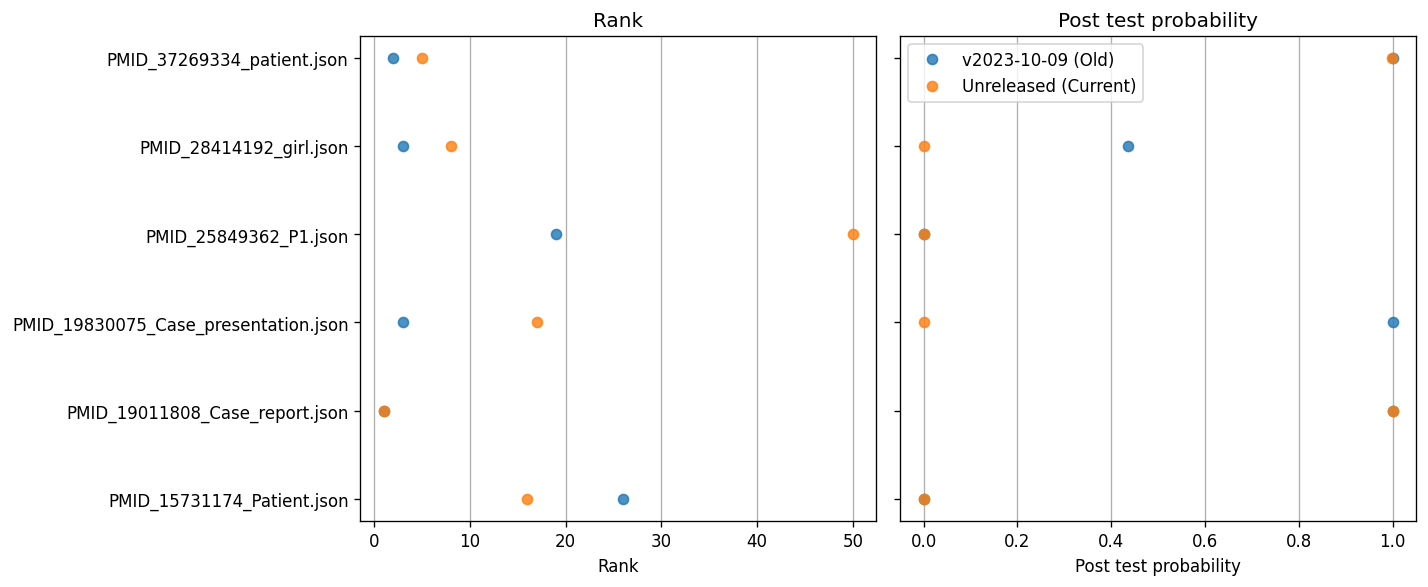

In [33]:
fig, (ax_ranks, ax_probas) = plt.subplots(1, 2, figsize=(12, 5), dpi=120, sharey=True)

ax_ranks.grid(axis='x')
ax_ranks.plot(df_old_data['rank'], df_old_data.index, 'o', alpha=.8, label='v2023-10-09 (Old)')
# ax_ranks.plot(df_latest_data['rank'], df_latest_data.index, 'o', alpha=.8, label='v2025-10-22 (Latest)')
ax_ranks.plot(df_current_data['rank'], df_current_data.index, 'o', alpha=.8, label='Current')
ax_ranks.set(xlabel='Rank', title='Rank')

ax_probas.grid(axis='x')
ax_probas.plot(df_old_data['post_test_proba'], df_old_data.index, 'o', alpha=.8, label='v2023-10-09 (Old)')
# ax_probas.plot(df_latest_data['post_test_proba'], df_latest_data.index, 'o', alpha=.8, label='v2025-10-22 (Latest)')
ax_probas.plot(df_current_data['post_test_proba'], df_current_data.index, 'o', alpha=.8, label='Unreleased (Current)')
ax_probas.set(xlabel='Post test probability', title='Post test probability')
ax_probas.legend()

fig.tight_layout()

### Rank distributions

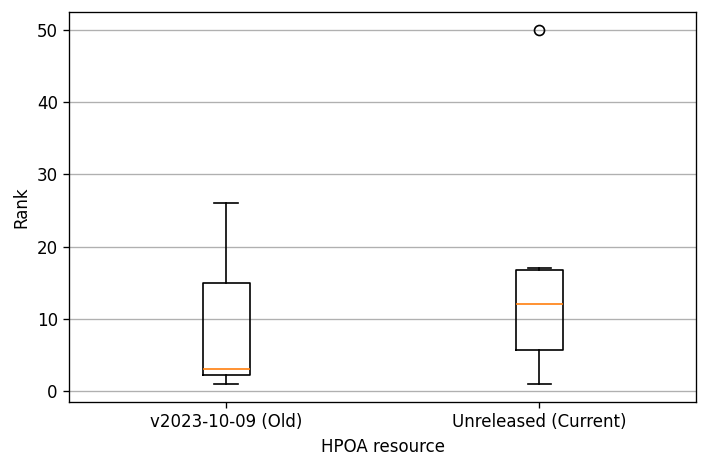

In [34]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120,)

ax.grid(axis='y')
_ = ax.boxplot(
    x=[
        df_old_data['rank'],
        # df_latest_data['rank'],
        df_current_data['rank']
    ],
    tick_labels=(
        'v2023-10-09 (Old)',
        # 'v2025-10-22 (Latest)',
        'Unreleased (Current)',
    ),
)
ax.set(xlabel='HPOA resource', ylabel='Rank',)
fig.tight_layout()

### Actual ranks

In [35]:
pd.concat(
    (
        pd.Series(df_old_data['rank'], name='v2023-10-09 (Old)'),
        # pd.Series(df_latest_data['rank'], name='v2025-10-22 (Latest)'),
        pd.Series(df_current_data['rank'], name='Unreleased (Current)'),
    ),
    axis=1
)


,v2023-10-09 (Old),Unreleased (Current)
phenopacket,,
PMID_15731174_Patient.json,26,16
PMID_19011808_Case_report.json,1,1
PMID_19830075_Case_presentation.json,3,17
PMID_25849362_P1.json,19,50
PMID_28414192_girl.json,3,8
PMID_37269334_patient.json,2,5


*-* EOF *-*